# Executive Producer Project



**Set `DATA_PATH` in the next cell, then Run All.**

In [1]:
Trn_DATA_PATH = "C:\\Users\\jaket\\OneDrive\\Documents\\Sem8 Fa2026\\Erdos\\project\\tmdb-box-office-prediction\\train.csv"          # <- Training data path)
Tst_DATA_PATH = "C:\\Users\\jaket\\OneDrive\\Documents\\Sem8 Fa2026\\Erdos\\project\\tmdb-box-office-prediction\\test.csv"            # <- Test data path
OUTDIR = "C:\\Users\\jaket\\OneDrive\\Documents\\Sem8 Fa2026\\Erdos\\project\\movie_analysis_output"  # charts and tables are also saved here

In [2]:
#pip install pandas matplotlib seaborn scikit-learn

In [3]:
import ast
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def section(title):
    print("\n" + "=" * 80 + f"\n{title.upper()}\n" + "=" * 80)

%matplotlib inline
sns.set_theme(style="whitegrid")
OUT = Path(OUTDIR); OUT.mkdir(parents=True, exist_ok=True)

## 1. Load the data
Column names are normalised (`méta_score` → `meta_score`), and empty strings, `[]` and `N/A` count as missing.

In [4]:
def load(path):
    ext = Path(path).suffix.lower()
    if ext in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    elif ext == ".json":
        df = pd.read_json(path)
    elif ext == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)
    # Normalise column names (e.g. "méta_score" -> "meta_score")
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace("é", "e").str.replace(" ", "_"))
    # Treat empty strings / placeholder text as missing
    df = df.replace(r"^\s*$", np.nan, regex=True)
    df = df.replace(["[]", "N/A", "n/a", "None", "nan", "-"], np.nan)
    return df

In [5]:
df_trn = load(Trn_DATA_PATH)
print(f"{len(df_trn):,} rows x {df_trn.shape[1]} columns")
df_trn.head()

3,000 rows x 23 columns


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [6]:
df_tst = load(Tst_DATA_PATH)
print(f"{len(df_tst):,} rows x {df_tst.shape[1]} columns")
df_tst.head()

4,398 rows x 22 columns


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,keywords,cast,crew
0,3001,"[{'id': 34055, 'name': 'Pokémon Collection', '...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 16, '...",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends (this time accompanied by newc...,3.851534,/tnftmLMemPLduW6MRyZE0ZUD19z.jpg,NaN,"[{'iso_3166_1': 'JP', 'name': 'Japan'}, {'iso_...",7/14/07,90.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Somewhere Between Time & Space... A Legend Is ...,Pokémon: The Rise of Darkrai,"[{'id': 11451, 'name': 'pok√©mon'}, {'id': 115...","[{'cast_id': 3, 'character': 'Tonio', 'credit_...","[{'credit_id': '52fe44e7c3a368484e03d683', 'de..."
1,3002,NaN,88000,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,tt0051380,en,Attack of the 50 Foot Woman,When an abused wife grows to giant size becaus...,3.559789,/9MgBNBqlH1sG4yG2u4XkwI5CoJa.jpg,"[{'name': 'Woolner Brothers Pictures Inc.', 'i...","[{'iso_3166_1': 'US', 'name': 'United States o...",5/19/58,65.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A titanic beauty spreads a macabre wave of hor...,Attack of the 50 Foot Woman,"[{'id': 9748, 'name': 'revenge'}, {'id': 9951,...","[{'cast_id': 2, 'character': 'Nancy Fowler Arc...","[{'credit_id': '55807805c3a3685b1300060b', 'de..."
2,3003,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0118556,en,Addicted to Love,Good-natured astronomer Sam is devastated when...,8.085194,/ed6nD7h9sbojSWY2qrnDcSvDFko.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",5/23/97,100.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Comedy About Lost Loves And Last Laughs,Addicted to Love,"[{'id': 931, 'name': 'jealousy'}, {'id': 9673,...","[{'cast_id': 11, 'character': 'Maggie', 'credi...","[{'credit_id': '52fe4330c3a36847f8041367', 'de..."
3,3004,NaN,6800000,"[{'id': 18, 'name': 'Drama'}, {'id': 10752, 'n...",http://www.sonyclassics.com/incendies/,tt1255953,fr,Incendies,A mother's last wishes send twins Jeanne and S...,8.596012,/sEUG3qjxwHjxkzuO7plrRHhOZUH.jpg,"[{'name': 'TS Productions', 'id': 313}, {'name...","[{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso...",9/4/10,130.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,The search began at the opening of their mothe...,Incendies,"[{'id': 378, 'name': 'prison'}, {'id': 539, 'n...","[{'cast_id': 6, 'character': 'Nawal', 'credit_...","[{'credit_id': '56478092c3a36826140043af', 'de..."
4,3005,NaN,2000000,"[{'id': 36, 'name': 'History'}, {'id': 99, 'na...",NaN,tt0418753,en,Inside Deep Throat,"In 1972, a seemingly typical shoestring budget...",3.217680,/n4WC3zbelz6SG7rhkWbf8m9pMHB.jpg,NaN,"[{'iso_3166_1': 'US', 'name': 'United States o...",2/11/05,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was filmed in 6 days for 25 thousand dollar...,Inside Deep Throat,"[{'id': 279, 'name': 'usa'}, {'id': 1228, 'nam...","[{'cast_id': 1, 'character': 'Narrator (voice)...","[{'credit_id': '52fe44ce9251416c75041967', 'de..."


## 2. Missing values
Ranks every column by missing count, names the worst one, and shows which columns tend to be missing together.

In [7]:
def missing_report(df, outdir):
    section("Missing values (raw columns)")
    miss = pd.DataFrame({
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
    }).sort_values("missing", ascending=False)
    print(miss)

    top = miss.index[0]
    print(f"\n>>> Column with the MOST missing values: '{top}' "
          f"({miss.loc[top, 'missing']:,} rows, {miss.loc[top, 'missing_%']}%)")

    # Rows with many gaps
    per_row = df.isna().sum(axis=1)
    print(f"\nRows with no missing values: {(per_row == 0).sum():,} of {len(df):,}")
    print(f"Average missing fields per row: {per_row.mean():.2f}")

    # Do columns tend to be missing together?
    m = df.isna().astype(int)
    m = m.loc[:, m.std() > 0]
    if m.shape[1] >= 2:
        co = m.corr()
        pairs = (co.where(np.triu(np.ones(co.shape, dtype=bool), k=1)).stack().dropna()
                   .sort_values(ascending=False))
        print("\nColumns most often missing TOGETHER (correlation of missingness):")
        print(pairs.head(8).round(3).to_string())

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(co, cmap="Blues", vmin=0, vmax=1, square=True, ax=ax)
        ax.set_title("Missingness correlation")
        fig.tight_layout(); fig.savefig(outdir / "missingness_correlation.png", dpi=120); plt.show()

    fig, ax = plt.subplots(figsize=(8, 7))
    miss["missing_%"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
    fig.tight_layout(); fig.savefig(outdir / "missing_by_column.png", dpi=120); plt.show()

    miss.to_csv(outdir / "missing_values.csv")
    return miss


MISSING VALUES (RAW COLUMNS)
                       missing  missing_%
belongs_to_collection     2396      79.87
homepage                  2054      68.47
tagline                    597      19.90
keywords                   276       9.20
production_companies       156       5.20
production_countries        55       1.83
cast                        26       0.87
spoken_languages            20       0.67
crew                        16       0.53
overview                     8       0.27
genres                       7       0.23
runtime                      2       0.07
poster_path                  1       0.03
id                           0       0.00
budget                       0       0.00
original_language            0       0.00
imdb_id                      0       0.00
original_title               0       0.00
popularity                   0       0.00
release_date                 0       0.00
status                       0       0.00
title                        0       0.00
reve

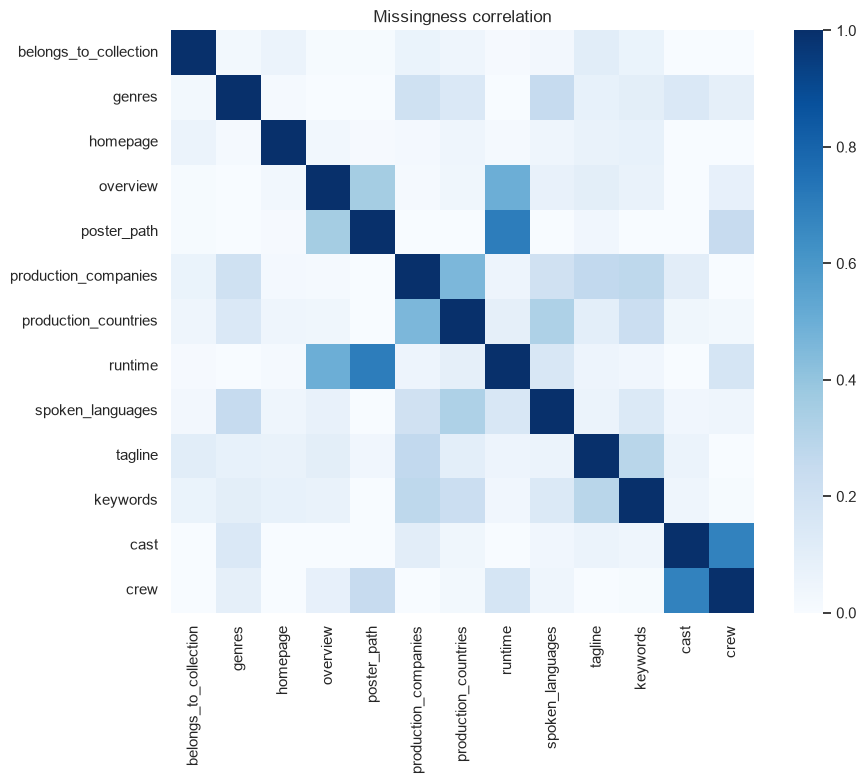

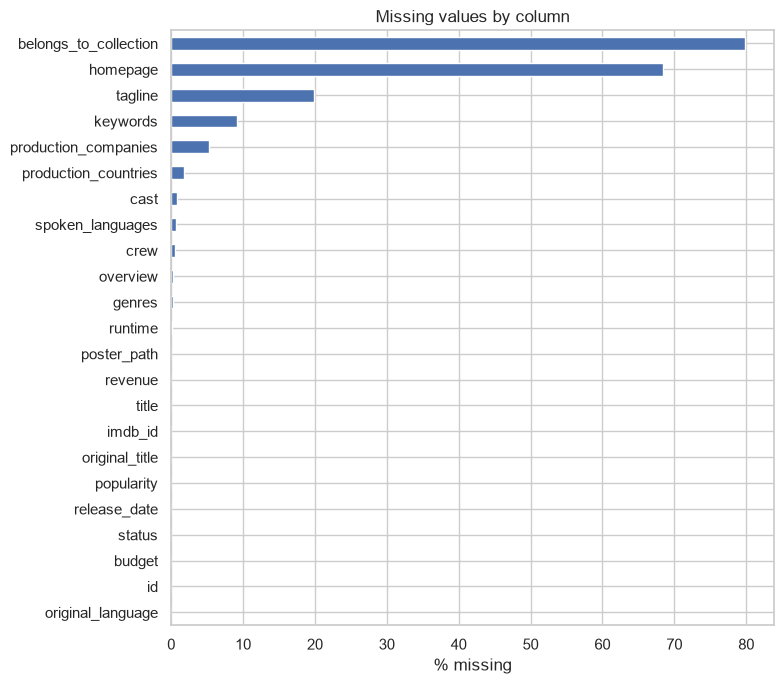


MISSING VALUES (RAW COLUMNS)
                       missing  missing_%
belongs_to_collection     3521      80.06
homepage                  2978      67.71
tagline                    863      19.62
keywords                   393       8.94
production_companies       258       5.87
production_countries       102       2.32
spoken_languages            42       0.95
cast                        34       0.77
crew                        22       0.50
genres                      16       0.36
overview                    14       0.32
runtime                      4       0.09
title                        3       0.07
status                       2       0.05
release_date                 1       0.02
poster_path                  1       0.02
id                           0       0.00
budget                       0       0.00
imdb_id                      0       0.00
original_title               0       0.00
popularity                   0       0.00
original_language            0       0.00

>>>

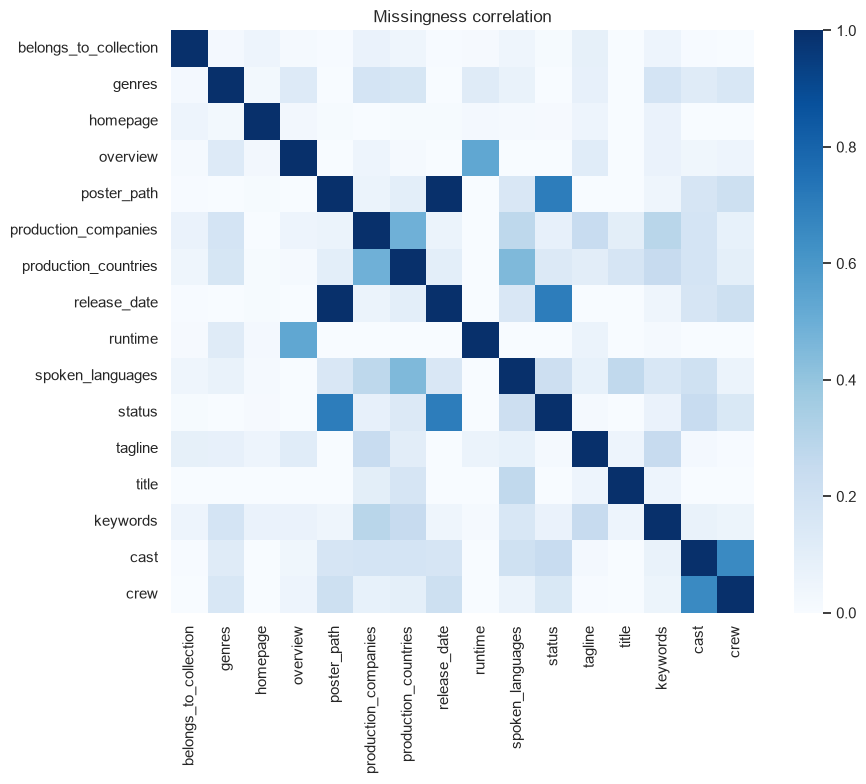

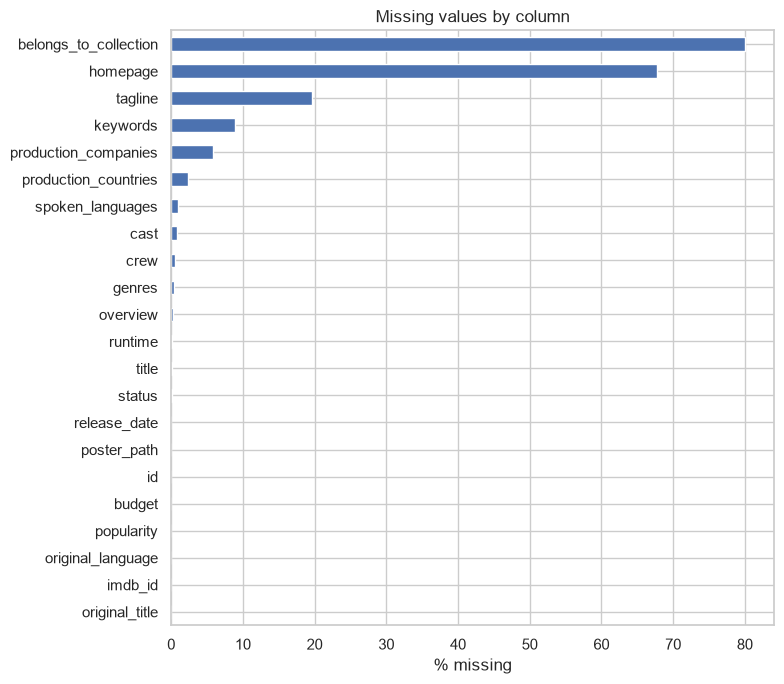

In [8]:
missing_Trn = missing_report(df_trn, OUT)
missing_Tst = missing_report(df_tst, OUT)


## 3. Turn text columns into numbers
Parsers for durations, vote counts, money, list columns and awards text. Money and votes also get a log version because they are heavily skewed.

In [9]:
def parse_duration(x):
    """'2h 22m' / '142 min' / '1h' / 142 -> minutes."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).lower()
    h = re.search(r"(\d+)\s*h", s)
    m = re.search(r"(\d+)\s*m", s)
    if h or m:
        return (int(h.group(1)) * 60 if h else 0) + (int(m.group(1)) if m else 0)
    num = re.search(r"\d+(\.\d+)?", s)
    return float(num.group()) if num else np.nan


def parse_count(x):
    """'2.9M' / '850K' / '1,234' -> number."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).upper().replace(",", "").strip()
    m = re.search(r"([\d.]+)\s*([KMB]?)", s)
    if not m:
        return np.nan
    mult = {"": 1, "K": 1e3, "M": 1e6, "B": 1e9}[m.group(2)]
    return float(m.group(1)) * mult


def parse_money(x):
    """'$25,000,000 (estimated)' / '€3.5M' -> number (currency symbol ignored)."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).replace(",", "")
    m = re.search(r"([\d.]+)\s*([KMB])?\b", s.upper())
    if not m:
        return np.nan
    mult = {None: 1, "K": 1e3, "M": 1e6, "B": 1e9}[m.group(2)]
    return float(m.group(1)) * mult


def parse_list(x):
    """"['Drama', 'Crime']" or 'Drama, Crime' -> ['Drama', 'Crime']."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if s.startswith("["):
        try:
            return [str(i).strip() for i in ast.literal_eval(s)]
        except (ValueError, SyntaxError):
            pass
    return [i.strip() for i in s.split(",") if i.strip()]


def count_awards(x, word):
    """Pull the number before e.g. 'wins' / 'nominations' from awards text."""
    if pd.isna(x):
        return np.nan
    m = re.search(rf"(\d+)\s*{word}", str(x).lower())
    return float(m.group(1)) if m else 0.0

In [10]:
def build_features(df):
    f = pd.DataFrame(index=df.index)

    if "duration" in df:
        f["duration_min"] = df["duration"].map(parse_duration)
    if "rating" in df:
        f["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    if "votes" in df:
        f["votes"] = df["votes"].map(parse_count)
        f["log_votes"] = np.log1p(f["votes"])
    if "meta_score" in df:
        f["meta_score"] = pd.to_numeric(df["meta_score"], errors="coerce")

    for col in ["budget", "opening_weekend_gross", "gross_worldwide", "gross_us_canada"]:
        if col in df:
            f[col] = df[col].map(parse_money)
            f[f"log_{col}"] = np.log1p(f[col])

    if {"budget", "gross_worldwide"} <= set(f.columns):
        f["roi"] = (f["gross_worldwide"] / f["budget"]).replace([np.inf, -np.inf], np.nan)

    if "release_date" in df:
        d = pd.to_datetime(df["release_date"], errors="coerce")
        f["release_year"] = d.dt.year
        f["release_month"] = d.dt.month

    # Number of items in list-like columns
    for col in ["writers", "directors", "stars", "countries_origin",
                "filming_locations", "production_companies", "genres", "languages"]:
        if col in df:
            f[f"n_{col}"] = df[col].map(lambda v: len(parse_list(v)))

    if "awards_content" in df:
        f["award_wins"] = df["awards_content"].map(lambda v: count_awards(v, "win"))
        f["award_noms"] = df["awards_content"].map(lambda v: count_awards(v, "nomination"))
    if "description" in df:
        f["description_len"] = df["description"].astype("string").str.len()

    return f

In [11]:
f_trn = build_features(df_trn)
f_trn.to_csv(OUT / "parsed_features.csv", index=False)
f_trn.describe().T.round(2)

C:\Users\jaket\AppData\Local\Temp\ipykernel_7984\2500566199.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d = pd.to_datetime(df["release_date"], errors="coerce")


,count,mean,std,min,25%,50%,75%,max
budget,3000.0,22531334.11,37026086.41,0.0,0.0,8000000.00,29000000.00,3.800000e+08
log_budget,3000.0,11.88,7.44,0.0,0.0,15.89,17.18,1.976000e+01
release_year,3000.0,2006.31,17.24,1976.0,1996.0,2006.00,2013.00,2.075000e+03
release_month,3000.0,6.78,3.41,1.0,4.0,7.00,10.00,1.200000e+01
n_production_companies,3000.0,2.70,2.01,0.0,1.0,2.00,4.00,1.700000e+01
n_genres,3000.0,2.50,1.12,0.0,2.0,2.00,3.00,7.000000e+00


Check the table above: if a column is all `NaN`, its text format differs from what the parsers expect. Look at a few raw values with `df["budget"].dropna().head()` and adjust the matching parser.

In [12]:
f_tst = build_features(df_tst)
f_tst.to_csv(OUT / "parsed_features.csv", index=False)
f_tst.describe().T.round(2)

C:\Users\jaket\AppData\Local\Temp\ipykernel_7984\2500566199.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d = pd.to_datetime(df["release_date"], errors="coerce")


,count,mean,std,min,25%,50%,75%,max
budget,4398.0,22649291.12,36899910.88,0.0,0.0,7450000.00,28000000.00,2.600000e+08
log_budget,4398.0,11.78,7.48,0.0,0.0,15.82,17.15,1.938000e+01
release_year,4397.0,2006.52,17.91,1976.0,1996.0,2006.00,2013.00,2.075000e+03
release_month,4397.0,6.89,3.37,1.0,4.0,7.00,10.00,1.200000e+01
n_production_companies,4398.0,2.78,2.30,0.0,1.0,2.00,4.00,2.600000e+01
n_genres,4398.0,2.49,1.12,0.0,2.0,2.00,3.00,8.000000e+00


## 4. Numeric correlations
- **Pearson**: straight-line relationships
- **Spearman**: monotonic relationships, robust to outliers (best default here)
- **Kendall**: rank-based, more conservative

Pairs need at least 30 movies with both values.

In [13]:
def top_pairs(corr, n=12):
    p = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().dropna()
             .rename("r").reset_index())
    p.columns = ["var_1", "var_2", "r"]
    return p.reindex(p["r"].abs().sort_values(ascending=False).index).head(n)


def numeric_correlations(f, outdir):
    # Skip raw money/vote columns when a log version exists (avoids duplicates)
    cols = [c for c in f.columns if not (f"log_{c}" in f.columns)]
    num = f[cols].loc[:, f[cols].nunique() > 1]

    results = {}
    for method in ["pearson", "spearman", "kendall"]:
        section(f"{method.title()} correlation")
        c = num.corr(method=method, min_periods=30)
        results[method] = c
        print(top_pairs(c).round(3).to_string(index=False))
        c.round(4).to_csv(outdir / f"corr_{method}.csv")

        fig, ax = plt.subplots(figsize=(13, 11))
        sns.heatmap(c, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                    annot=len(c) <= 18, fmt=".2f", annot_kws={"size": 7}, square=True, ax=ax)
        ax.set_title(f"{method.title()} correlation")
        fig.tight_layout(); fig.savefig(outdir / f"heatmap_{method}.png", dpi=120); plt.show()

    # Significance of the Pearson pairs that matter most
    section("Significance of key pairs (Pearson, with p-values)")
    rows = []
    for _, r in top_pairs(results["pearson"], 15).iterrows():
        pair = num[[r.var_1, r.var_2]].dropna()
        rho, p = stats.pearsonr(pair[r.var_1], pair[r.var_2])
        rows.append([r.var_1, r.var_2, len(pair), round(rho, 3), f"{p:.2e}"])
    print(pd.DataFrame(rows, columns=["var_1", "var_2", "n", "r", "p_value"]).to_string(index=False))

    # What correlates with the main outcomes
    for target in ["rating", "meta_score", "log_gross_worldwide"]:
        if target in num:
            section(f"What correlates with {target} (Spearman)")
            s = results["spearman"][target].drop(target).dropna()
            print(s.reindex(s.abs().sort_values(ascending=False).index).round(3).to_string())
    return results



PEARSON CORRELATION
                 var_1                  var_2      r
            log_budget n_production_companies  0.197
            log_budget               n_genres  0.189
          release_year n_production_companies  0.054
n_production_companies               n_genres  0.053
            log_budget          release_month  0.048
            log_budget           release_year  0.043
          release_year               n_genres -0.028
         release_month n_production_companies -0.014
         release_month               n_genres -0.011
          release_year          release_month  0.001


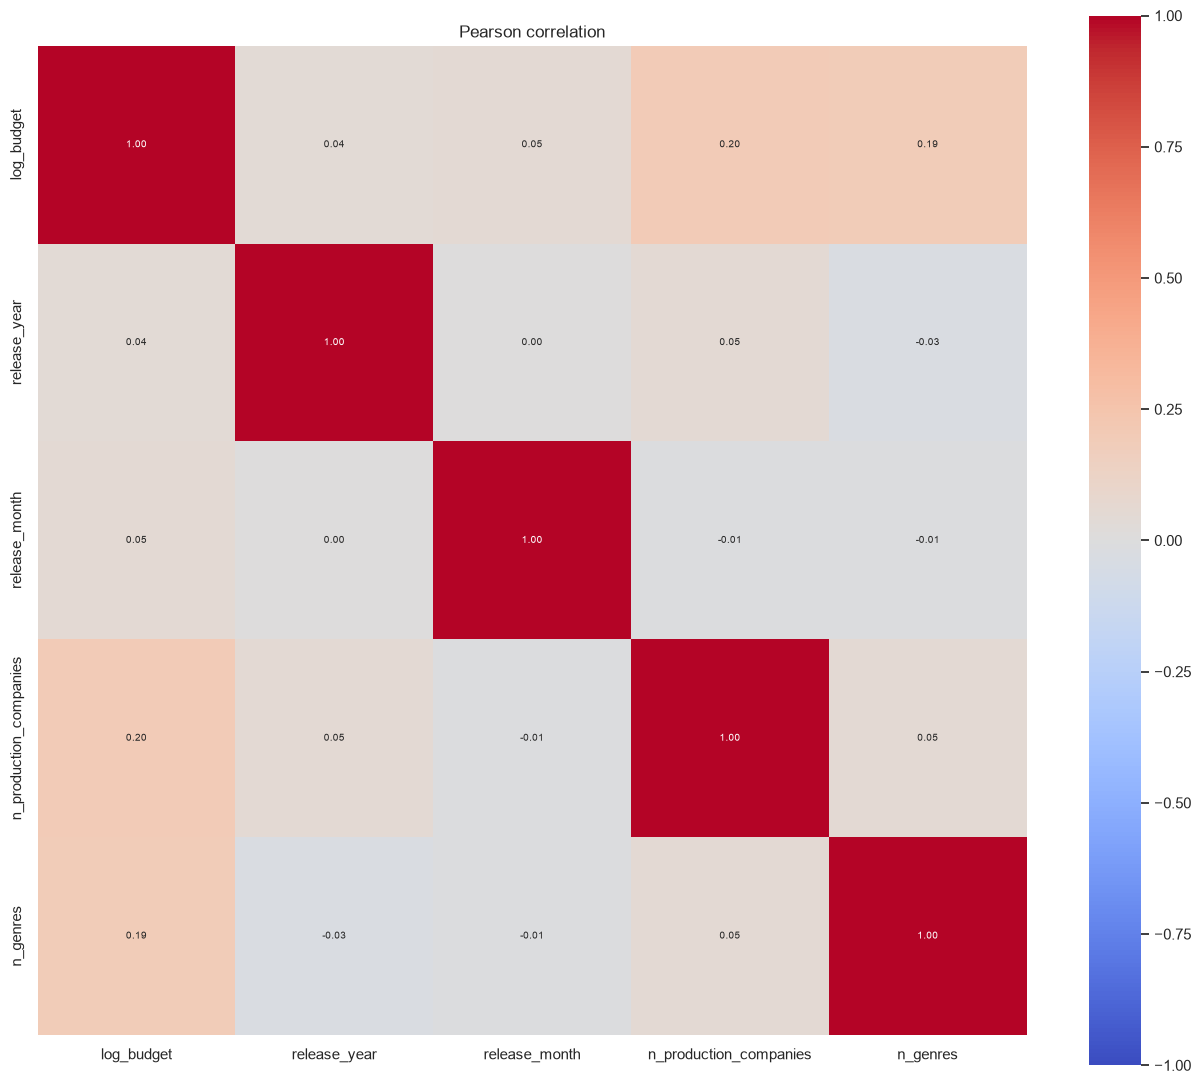


SPEARMAN CORRELATION
                 var_1                  var_2      r
            log_budget n_production_companies  0.325
            log_budget               n_genres  0.255
          release_year n_production_companies  0.165
n_production_companies               n_genres  0.076
          release_year               n_genres -0.071
            log_budget          release_month  0.052
          release_year          release_month -0.026
            log_budget           release_year  0.024
         release_month n_production_companies -0.021
         release_month               n_genres -0.008


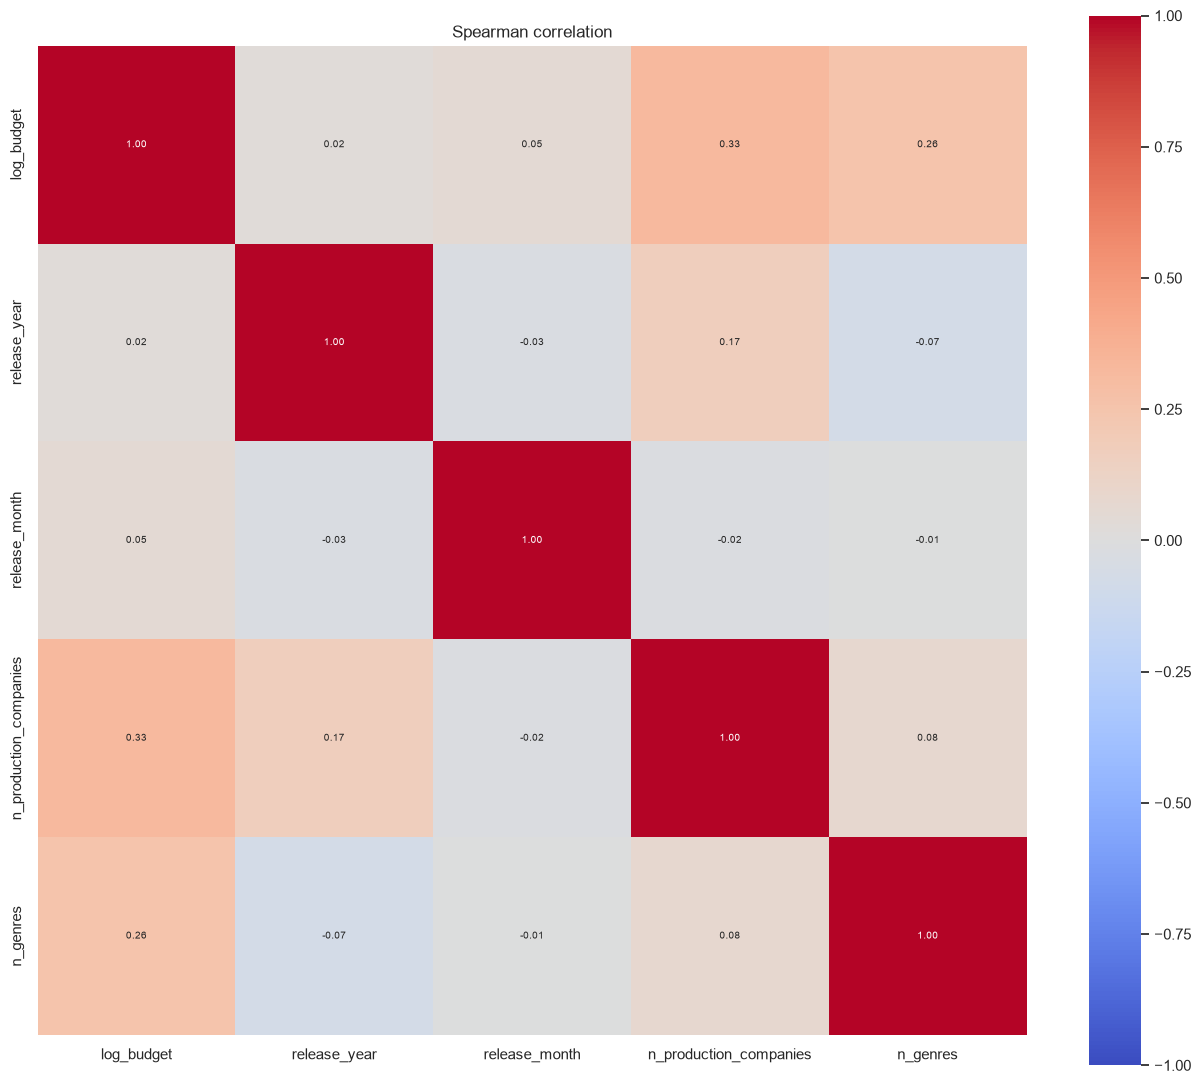


KENDALL CORRELATION
                 var_1                  var_2      r
            log_budget n_production_companies  0.246
            log_budget               n_genres  0.196
          release_year n_production_companies  0.122
n_production_companies               n_genres  0.062
          release_year               n_genres -0.053
            log_budget          release_month  0.038
          release_year          release_month -0.018
            log_budget           release_year  0.018
         release_month n_production_companies -0.016
         release_month               n_genres -0.006


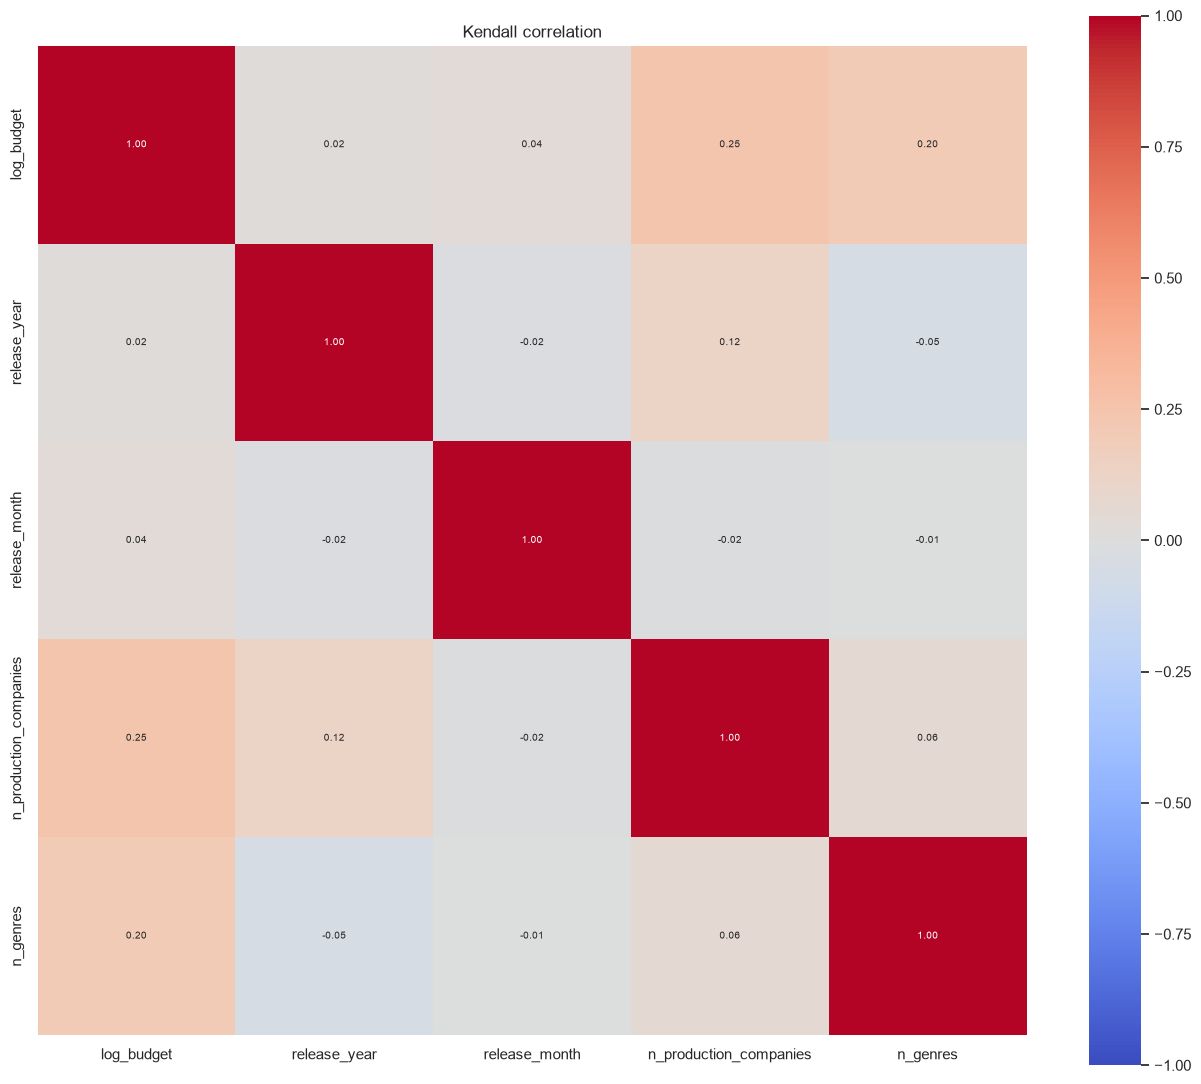


SIGNIFICANCE OF KEY PAIRS (PEARSON, WITH P-VALUES)
                 var_1                  var_2    n      r  p_value
            log_budget n_production_companies 3000  0.197 1.46e-27
            log_budget               n_genres 3000  0.189 1.41e-25
          release_year n_production_companies 3000  0.054 3.13e-03
n_production_companies               n_genres 3000  0.053 3.96e-03
            log_budget          release_month 3000  0.048 8.75e-03
            log_budget           release_year 3000  0.043 1.84e-02
          release_year               n_genres 3000 -0.028 1.31e-01
         release_month n_production_companies 3000 -0.014 4.48e-01
         release_month               n_genres 3000 -0.011 5.35e-01
          release_year          release_month 3000  0.001 9.41e-01


In [14]:
#TRAINING DATASET CORRELATIONS

corrs_trn = numeric_correlations(f_trn, OUT)

   



PEARSON CORRELATION
                 var_1                  var_2      r
            log_budget               n_genres  0.186
            log_budget n_production_companies  0.182
n_production_companies               n_genres  0.065
            log_budget           release_year  0.059
            log_budget          release_month  0.057
          release_year n_production_companies  0.039
         release_month n_production_companies  0.026
          release_year               n_genres -0.019
         release_month               n_genres  0.009
          release_year          release_month  0.004


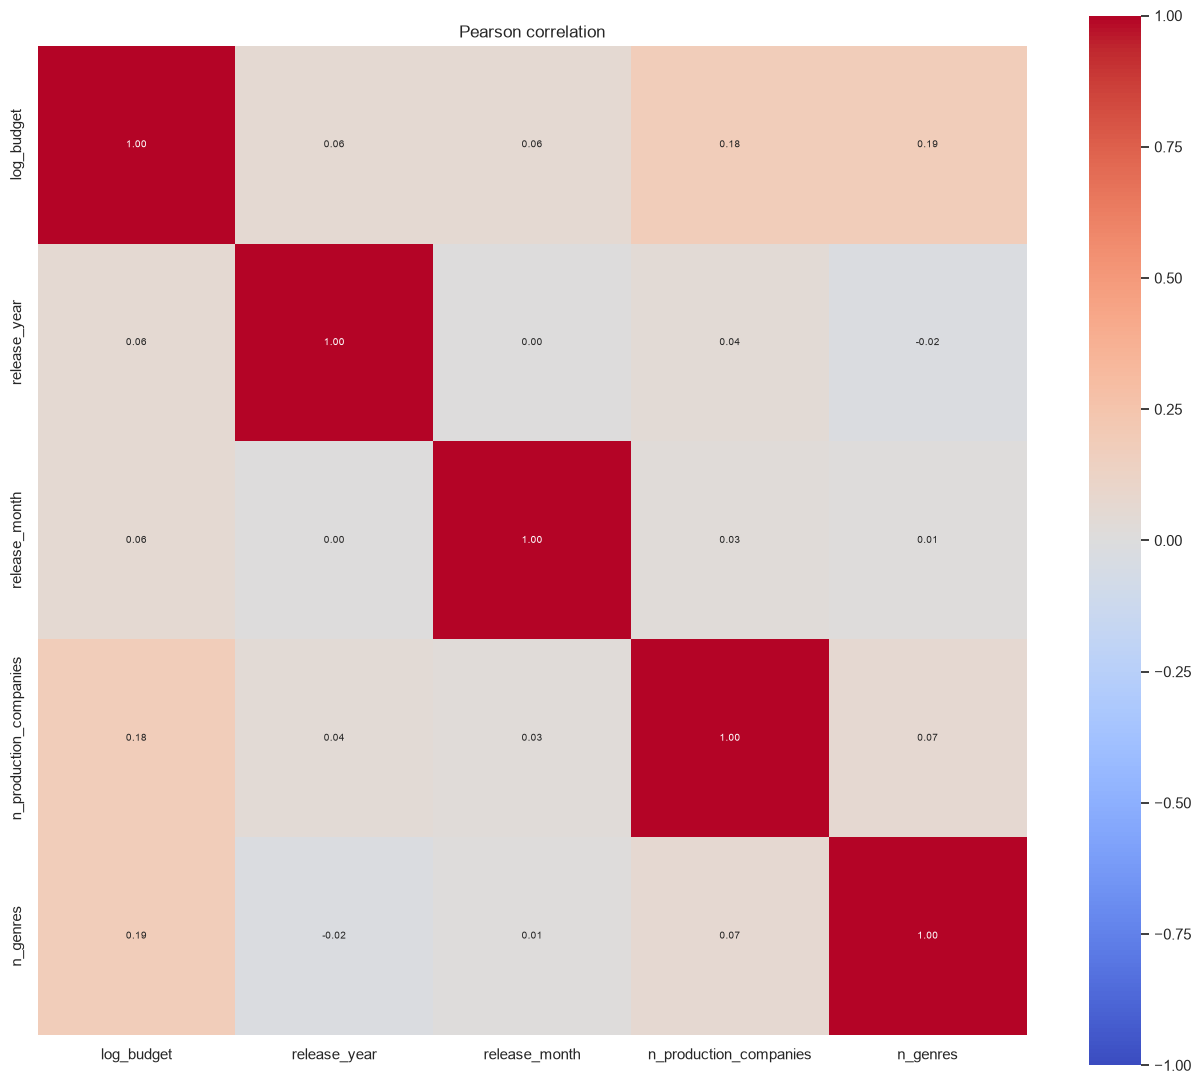


SPEARMAN CORRELATION
                 var_1                  var_2      r
            log_budget n_production_companies  0.326
            log_budget               n_genres  0.257
          release_year n_production_companies  0.159
n_production_companies               n_genres  0.090
            log_budget          release_month  0.066
          release_year               n_genres -0.053
         release_month n_production_companies  0.038
            log_budget           release_year  0.036
          release_year          release_month -0.017
         release_month               n_genres  0.006


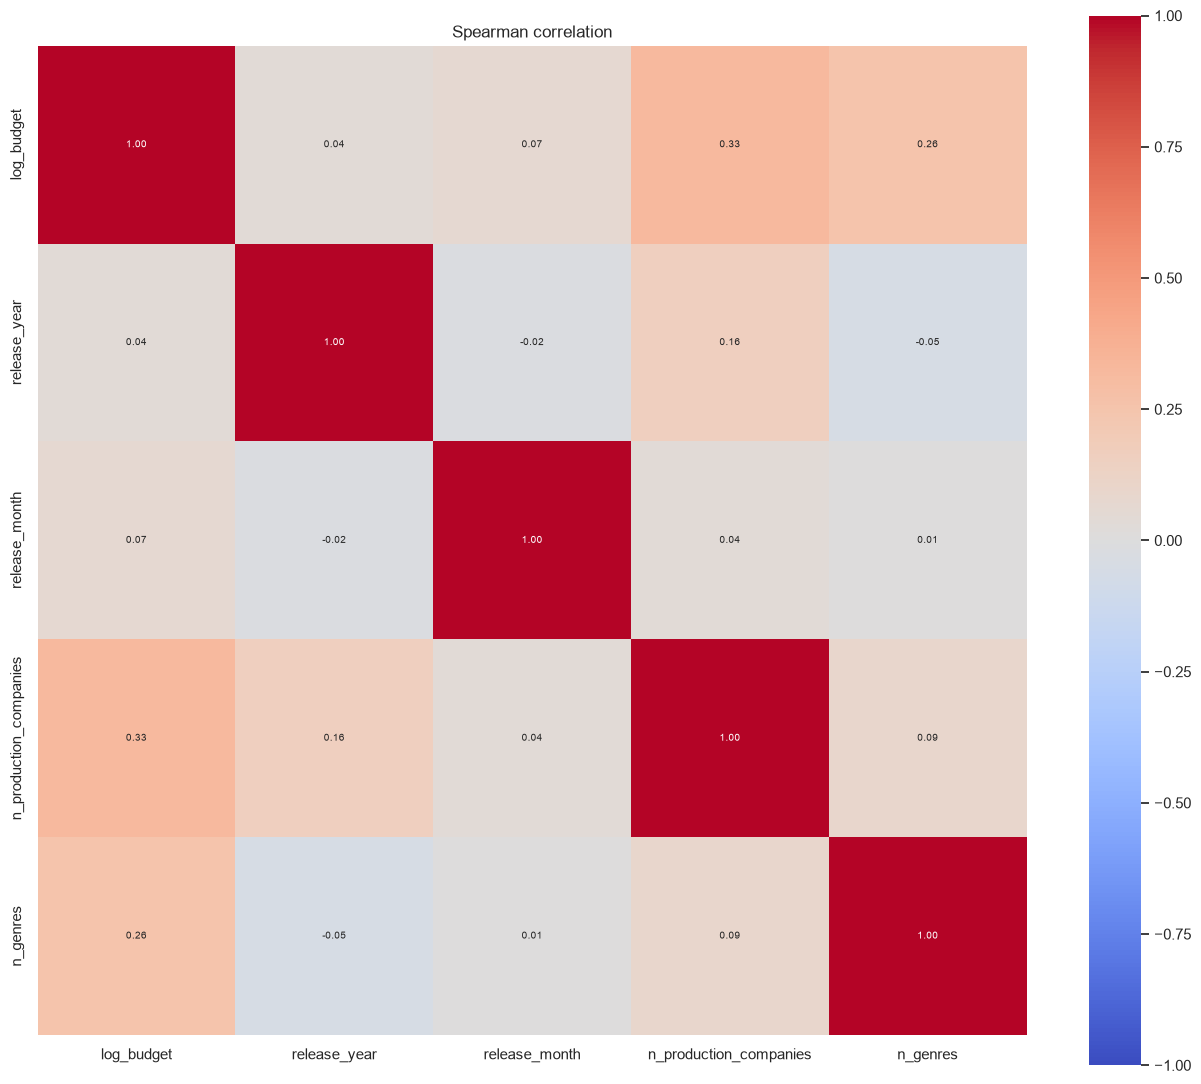


KENDALL CORRELATION
                 var_1                  var_2      r
            log_budget n_production_companies  0.246
            log_budget               n_genres  0.198
          release_year n_production_companies  0.117
n_production_companies               n_genres  0.073
            log_budget          release_month  0.047
          release_year               n_genres -0.039
         release_month n_production_companies  0.028
            log_budget           release_year  0.028
          release_year          release_month -0.012
         release_month               n_genres  0.004


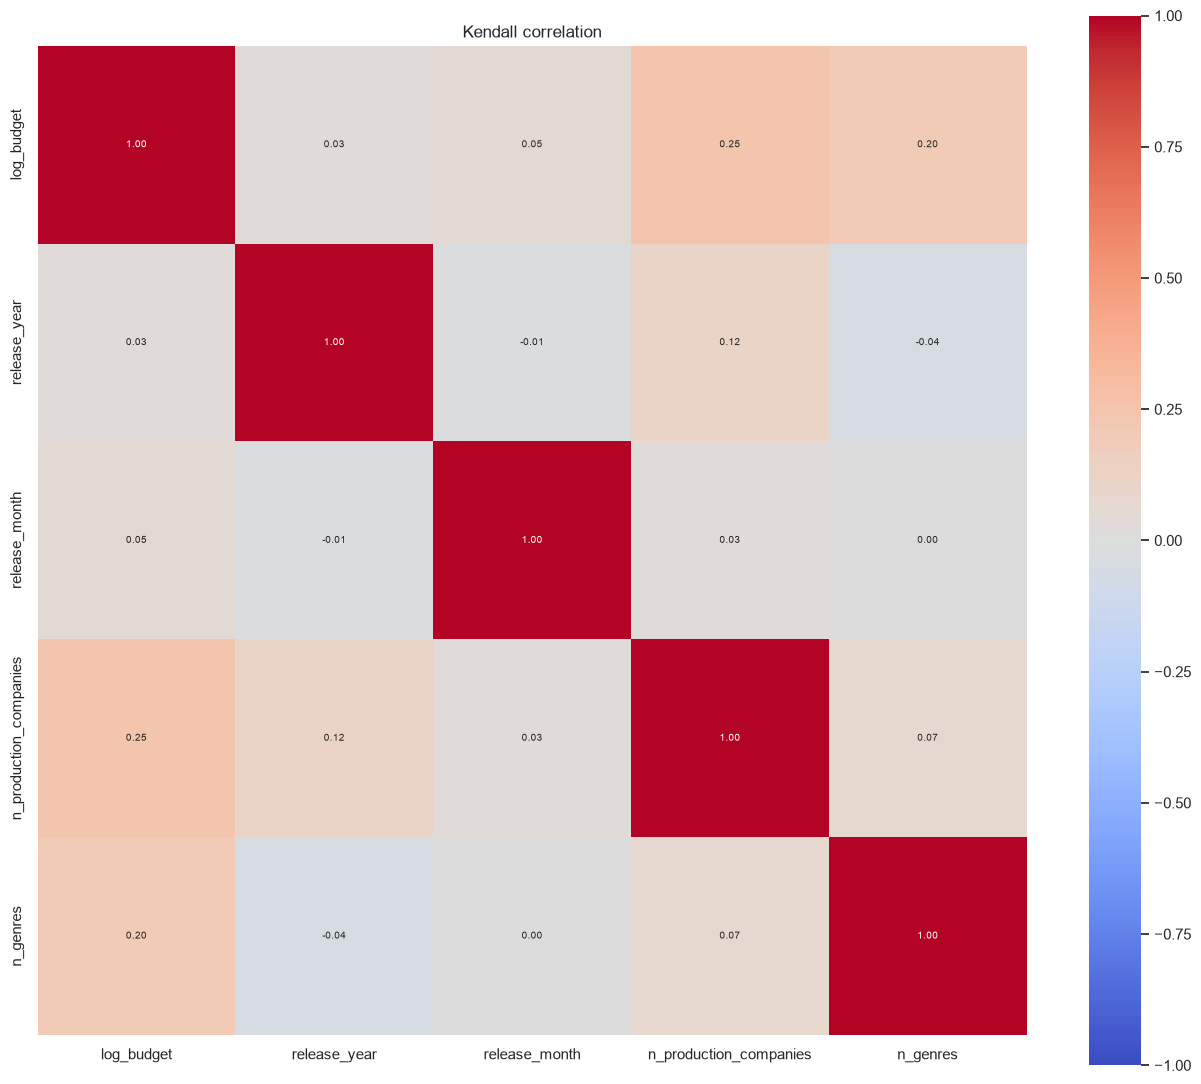


SIGNIFICANCE OF KEY PAIRS (PEARSON, WITH P-VALUES)
                 var_1                  var_2    n      r  p_value
            log_budget               n_genres 4398  0.186 1.29e-35
            log_budget n_production_companies 4398  0.182 5.27e-34
n_production_companies               n_genres 4398  0.065 1.44e-05
            log_budget           release_year 4397  0.059 8.39e-05
            log_budget          release_month 4397  0.057 1.74e-04
          release_year n_production_companies 4397  0.039 8.92e-03
         release_month n_production_companies 4397  0.026 8.25e-02
          release_year               n_genres 4397 -0.019 1.97e-01
         release_month               n_genres 4397  0.009 5.30e-01
          release_year          release_month 4397  0.004 7.90e-01


In [15]:
# Test dataset correlations
corrs_tst = numeric_correlations(f_tst, OUT) 

## 5. Categorical correlations
- **MPA rating**: correlation ratio η (0 = no relationship, 1 = fully determined)
- **Genres**: point-biserial correlation of each genre flag with rating, votes, gross, etc. (genres with 20+ movies)

In [16]:
def categorical_correlations(df, f, outdir):
    """MPA rating vs numeric features (correlation ratio, eta) and genre effects."""
    numeric_targets = [c for c in ["rating", "meta_score", "log_votes", "log_gross_worldwide",
                                   "log_budget", "duration_min"] if c in f]

    if "mpa" in df:
        section("MPA rating vs numeric features (correlation ratio η, 0–1)")
        def eta(cat, y):
            d = pd.DataFrame({"c": cat, "y": y}).dropna()
            if d["c"].nunique() < 2:
                return np.nan
            grand = d["y"].mean()
            between = d.groupby("c")["y"].apply(lambda g: len(g) * (g.mean() - grand) ** 2).sum()
            total = ((d["y"] - grand) ** 2).sum()
            return np.sqrt(between / total) if total else np.nan
        print(pd.Series({t: eta(df["mpa"], f[t]) for t in numeric_targets}).round(3).to_string())
        print("\nMean by MPA rating:")
        print(f[numeric_targets].groupby(df["mpa"]).mean().round(2))

    if "genres" in df:
        section("Genre vs rating / gross (point-biserial correlation)")
        genre_lists = df["genres"].map(parse_list)
        dummies = genre_lists.explode().str.strip().pipe(pd.get_dummies).groupby(level=0).max()
        dummies = dummies.reindex(df.index, fill_value=0).astype(int)
        dummies = dummies.loc[:, dummies.sum() >= 20]  # only reasonably common genres
        out = {}
        for t in numeric_targets:
            out[t] = dummies.apply(lambda g: f[t].corr(g))
        genre_corr = pd.DataFrame(out)
        genre_corr["n_movies"] = dummies.sum()
        print(genre_corr.sort_values(numeric_targets[0], ascending=False).round(3))
        genre_corr.to_csv(outdir / "genre_correlations.csv")

        if len(genre_corr) > 1:
            fig, ax = plt.subplots(figsize=(8, max(4, len(genre_corr) * 0.35)))
            sns.heatmap(genre_corr[numeric_targets], cmap="coolwarm", center=0,
                        annot=True, fmt=".2f", ax=ax)
            ax.set_title("Genre correlation with outcomes")
            fig.tight_layout(); fig.savefig(outdir / "genre_correlations.png", dpi=120); plt.show()



GENRE VS RATING / GROSS (POINT-BISERIAL CORRELATION)
                                        log_budget  n_movies
{'id': 28, 'name': 'Action'}                 0.161       741
{'id': 12, 'name': 'Adventure'}              0.152       439
{'id': 53, 'name': 'Thriller'}               0.115       789
{'id': 878, 'name': 'Science Fiction'}       0.113       290
{'id': 14, 'name': 'Fantasy'}                0.082       232
{'id': 80, 'name': 'Crime'}                  0.077       469
{'id': 10751, 'name': 'Family'}              0.054       260
{'id': 9648, 'name': 'Mystery'}              0.050       225
{'id': 10752, 'name': 'War'}                 0.040       100
{'id': 27, 'name': 'Horror'}                 0.039       301
{'id': 36, 'name': 'History'}                0.032       132
{'id': 16, 'name': 'Animation'}              0.031       141
{'id': 37, 'name': 'Western'}               -0.005        43
{'id': 10402, 'name': 'Music'}              -0.018       100
{'id': 10749, 'name': 'Romance'

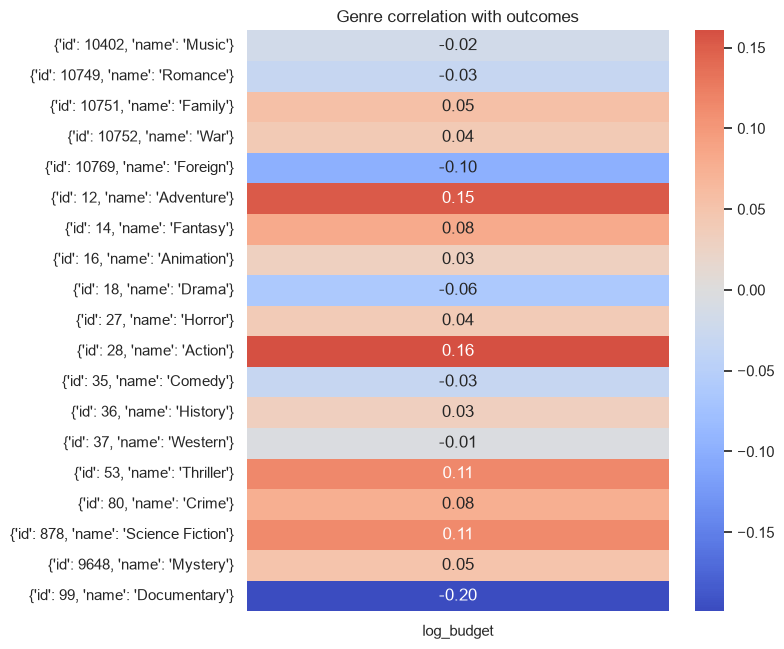

In [17]:
# TRAINING DATASET CATEGORICAL CORRELATIONS
categorical_correlations(df_trn, f_trn, OUT)



GENRE VS RATING / GROSS (POINT-BISERIAL CORRELATION)
                                        log_budget  n_movies
{'id': 12, 'name': 'Adventure'}              0.179       677
{'id': 28, 'name': 'Action'}                 0.137       994
{'id': 878, 'name': 'Science Fiction'}       0.118       454
{'id': 53, 'name': 'Thriller'}               0.109      1080
{'id': 14, 'name': 'Fantasy'}                0.092       396
{'id': 10751, 'name': 'Family'}              0.086       415
{'id': 80, 'name': 'Crime'}                  0.057       615
{'id': 9648, 'name': 'Mystery'}              0.057       325
{'id': 10752, 'name': 'War'}                 0.051       143
{'id': 16, 'name': 'Animation'}              0.051       241
{'id': 36, 'name': 'History'}                0.039       163
{'id': 27, 'name': 'Horror'}                 0.023       434
{'id': 37, 'name': 'Western'}                0.017        74
{'id': 10402, 'name': 'Music'}              -0.002       167
{'id': 35, 'name': 'Comedy'}   

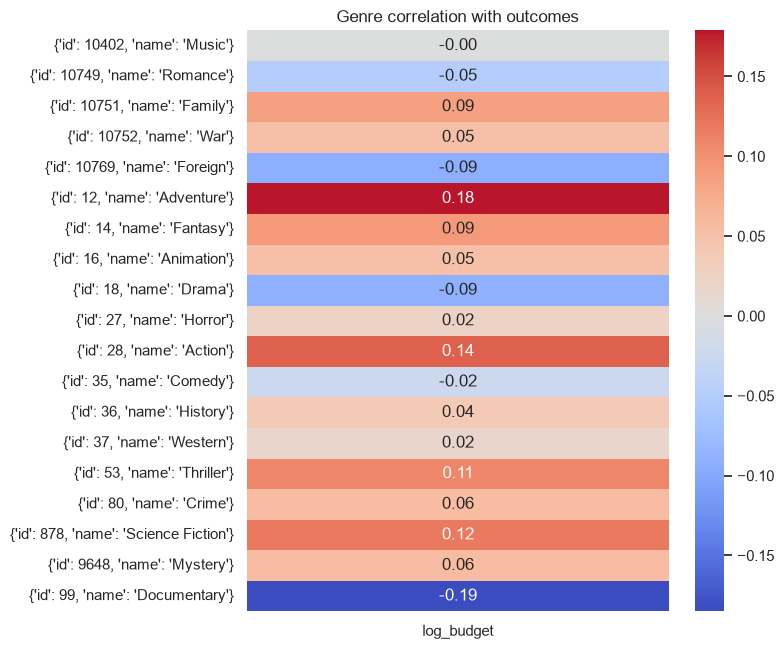

In [18]:
#TEST DATASET CATEGORICAL CORRELATIONS
categorical_correlations(df_tst, f_tst, OUT)

## 6. Key relationships

In [19]:
#Training dataset feature engineering
if "release_date" in df_trn:
        d = pd.to_datetime(df_trn["release_date"], errors="coerce")
        future = d > pd.Timestamp.today()
        d = d.where(~future, d - pd.DateOffset(years=100))
        f_trn["release_year"] = d.dt.year
        f_trn["release_month"] = d.dt.month

C:\Users\jaket\AppData\Local\Temp\ipykernel_7984\1660668377.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d = pd.to_datetime(df_trn["release_date"], errors="coerce")


In [20]:
for col in ["budget", "opening_weekend_gross", "gross_worldwide", "gross_us_canada"]:
    if col in f_trn:
        f_trn[col] = f_trn[col].replace(0, np.nan)
        f_trn[f"log_{col}"] = np.log1p(f_trn[col])

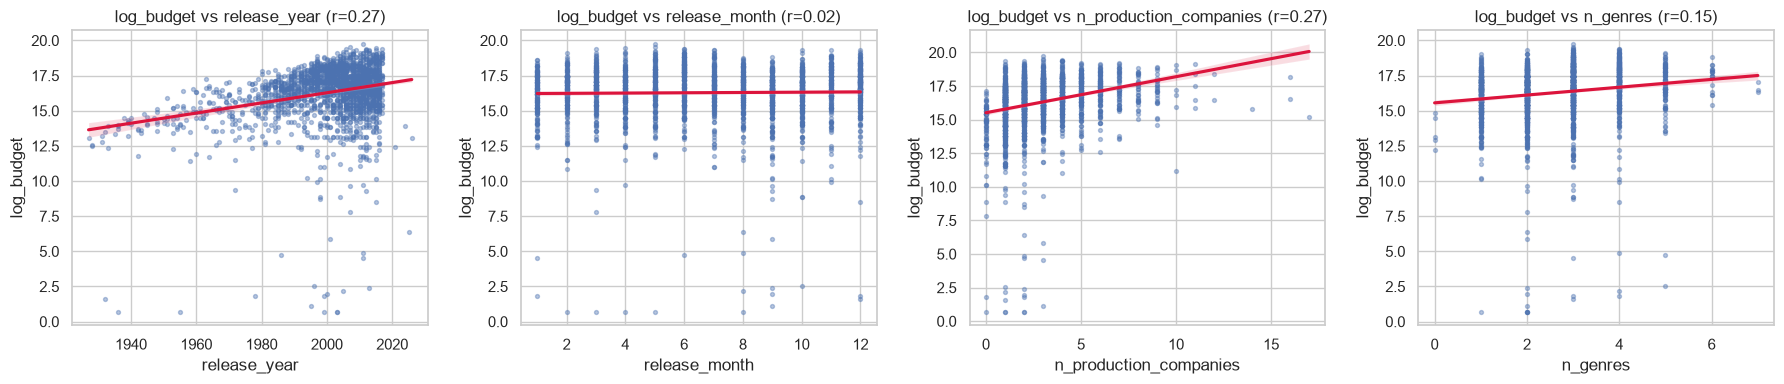

In [21]:
#Training dataset scatter plots
cols = [c for c in f_trn.select_dtypes("number").columns if c not in ("budget", "log_budget")]
fig, axes = plt.subplots(1, len(cols), figsize=(4.5 * len(cols), 4), squeeze=False)
for ax, c in zip(axes[0], cols):
    d = f_trn[["log_budget", c]].dropna()
    sns.regplot(data=d, x=c, y="log_budget", ax=ax,
                scatter_kws={"s": 8, "alpha": 0.4}, line_kws={"color": "crimson"})
    ax.set_title(f"log_budget vs {c} (r={d[c].corr(d['log_budget']):.2f})")
fig.tight_layout()
plt.show()

In [22]:
#Test dataset feature engineering

if "release_date" in df_tst:
        d = pd.to_datetime(df_tst["release_date"], errors="coerce")
        future = d > pd.Timestamp.today()
        d = d.where(~future, d - pd.DateOffset(years=100))
        f_tst["release_year"] = d.dt.year
        f_tst["release_month"] = d.dt.month

for col in ["budget", "opening_weekend_gross", "gross_worldwide", "gross_us_canada"]:
    if col in f_tst:
        f_tst[col] = f_tst[col].replace(0, np.nan)
        f_tst[f"log_{col}"] = np.log1p(f_tst[col])

C:\Users\jaket\AppData\Local\Temp\ipykernel_7984\9587588.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d = pd.to_datetime(df_tst["release_date"], errors="coerce")


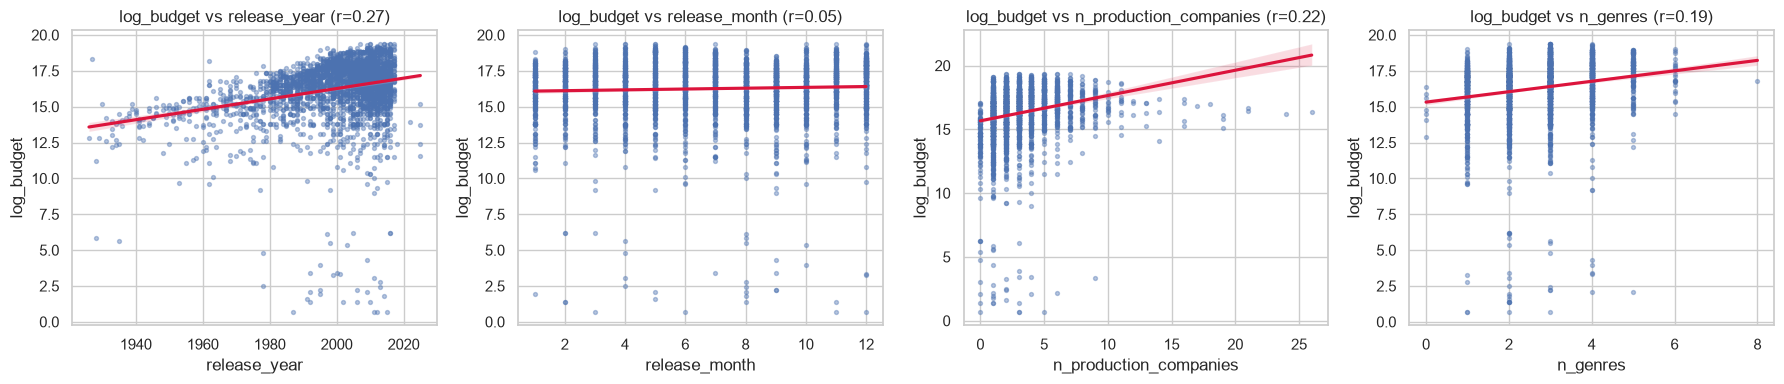

In [23]:
#Test dataset scatter plots

cols = [c for c in f_tst.select_dtypes("number").columns if c not in ("budget", "log_budget")]
fig, axes = plt.subplots(1, len(cols), figsize=(4.5 * len(cols), 4), squeeze=False)
for ax, c in zip(axes[0], cols):
    d = f_tst[["log_budget", c]].dropna()
    sns.regplot(data=d, x=c, y="log_budget", ax=ax,
                scatter_kws={"s": 8, "alpha": 0.4}, line_kws={"color": "crimson"})
    ax.set_title(f"log_budget vs {c} (r={d[c].corr(d['log_budget']):.2f})")
fig.tight_layout()
plt.show()